<a href="https://colab.research.google.com/github/NVHau-K14/Tuan03_ThucHanh_DeepLearning-/blob/main/ANN_NhanDangChuVietSo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Khai báo thư viện

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

Khai báo nhãn và tải bộ dữ liệu MNIST

In [3]:
# Khai báo danh sách các nhãn (từ Số 0 đến Số 9)
class_names = ['Số 0', 'Số 1', 'Số 2', 'Số 3', 'Số 4',
               'Số 5', 'Số 6', 'Số 7', 'Số 8', 'Số 9']

# Tải dataset MNIST
print("Đang tải dữ liệu MNIST...")
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
print(f"Đã tải xong! Kích thước tập huấn luyện: {x_train.shape}")
print(f"Kích thước tập kiểm tra: {x_test.shape}")

Đang tải dữ liệu MNIST...
Đã tải xong! Kích thước tập huấn luyện: (60000, 28, 28)
Kích thước tập kiểm tra: (10000, 28, 28)


Tiền xử lý dữ liệu

In [4]:
x_train = x_train / 255.0
x_test = x_test / 255.0
print("Đã chuẩn hóa dữ liệu xong!")

Đã chuẩn hóa dữ liệu xong!


Xây dựng cấu trúc mô hình ANN

In [5]:
model = models.Sequential([
    # Duỗi ảnh 2D (28x28) thành vector 1D (784)
    layers.Flatten(input_shape=(28, 28)),

    # Lớp ẩn với 128 nơ-ron
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),

    # Lớp đầu ra với 10 nơ-ron cho 10 chữ số
    layers.Dense(10, activation='softmax')
])

# Xem tóm tắt cấu trúc mô hình
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

Biên dịch mô hình (Compile)

In [6]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
print("Đã biên dịch mô hình, sẵn sàng huấn luyện!")

Đã biên dịch mô hình, sẵn sàng huấn luyện!


Huấn luyện mô hình (Training)

In [ ]:
print("Bắt đầu huấn luyện mô hình...")
history = model.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test))

Đánh giá mô hình (Evaluation)

In [24]:
print("\nĐánh giá mô hình trên tập Test:")
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f'\nĐộ chính xác trên tập kiểm tra (Test Accuracy): {test_acc*100:.2f}%')


Đánh giá mô hình trên tập Test:
313/313 - 1s - 3ms/step - accuracy: 0.9822 - loss: 0.0725

Độ chính xác trên tập kiểm tra (Test Accuracy): 98.22%


Hiển thị thử nghiệm (Prediction), Lấy ngẫu nhiên 5 bức ảnh đầu tiên trong tập test để xem mô hình dự đoán đúng hay sai.


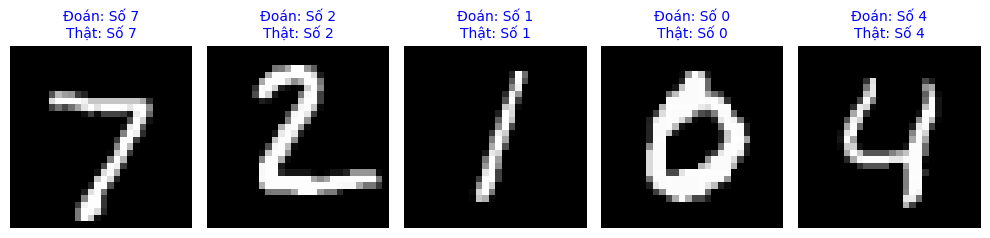

In [9]:
def plot_multiple_predictions(num_images=5):
    plt.figure(figsize=(10, 3))
    for i in range(num_images):
        plt.subplot(1, num_images, i+1)
        # Hiển thị ảnh xám (cmap='gray')
        plt.imshow(x_test[i], cmap='gray')

        # Mô hình dự đoán
        prediction = model.predict(np.expand_dims(x_test[i], axis=0), verbose=0)
        predicted_label = np.argmax(prediction)
        true_label = y_test[i]

        # Chữ xanh nếu đúng, đỏ nếu sai
        color = 'blue' if predicted_label == true_label else 'red'

        plt.title(f"Đoán: {class_names[predicted_label]}\nThật: {class_names[true_label]}", color=color, fontsize=10)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Chạy hàm hiển thị
plot_multiple_predictions(5)

Tải ảnh tự vẽ lên, thu nhỏ về 28x28, và đảo ngược màu, nền trắng chữ đen thành nền đen chữ trắng

Saving Untitled.png to Untitled (9).png


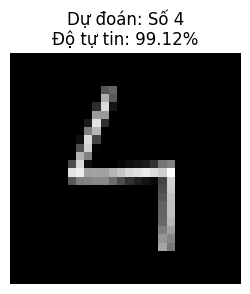

In [35]:
from google.colab import files
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

uploaded = files.upload()

for file_name in uploaded.keys():

    # 1. Đọc ảnh grayscale
    img = Image.open(file_name).convert('L')

    img_array = np.array(img)

    # 2. Nếu nền trắng chữ đen -> đảo màu
    if np.mean(img_array[:20, :20]) > 127:
        img_array = 255 - img_array

    # 3. Nhị phân hóa ảnh
    img_array = np.where(img_array > 50, 255, 0)

    # 4. Tìm vùng có chữ số (crop)
    coords = np.argwhere(img_array > 0)

    y_min, x_min = coords.min(axis=0)
    y_max, x_max = coords.max(axis=0)

    digit = img_array[y_min:y_max+1,
                      x_min:x_max+1]

    # 5. Resize chữ số về khoảng 20x20
    digit_img = Image.fromarray(digit.astype(np.uint8))
    digit_img.thumbnail((20, 20))

    digit_array = np.array(digit_img)

    # 6. Tạo canvas 28x28 nền đen
    canvas = np.zeros((28, 28))

    h, w = digit_array.shape

    x_offset = (28 - w) // 2
    y_offset = (28 - h) // 2

    canvas[y_offset:y_offset+h,
           x_offset:x_offset+w] = digit_array

    # 7. Chuẩn hóa
    canvas = canvas / 255.0

    # reshape
    input_img = canvas.reshape(1, 28, 28)

    # 8. Predict
    prediction = model.predict(input_img, verbose=0)

    predicted_label = np.argmax(prediction)
    confidence = np.max(prediction) * 100

    # 9. Hiển thị
    plt.figure(figsize=(3,3))
    plt.imshow(canvas, cmap='gray')
    plt.title(
        f"Dự đoán: {class_names[predicted_label]}\n"
        f"Độ tự tin: {confidence:.2f}%"
    )
    plt.axis('off')
    plt.show()